<a href="https://colab.research.google.com/github/Sunay-2103/SunayMukherjee_23FE10CSE00636/blob/main/DecisionTrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pandas as pd

seed_data = pd.read_csv('Seed_Data.csv')

display(seed_data.head())

,A,P,C,LK,WK,A_Coef,LKG,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


In [4]:
type(seed_data)

pandas.core.frame.DataFrame

In [7]:
seed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       210 non-null    float64
 1   P       210 non-null    float64
 2   C       210 non-null    float64
 3   LK      210 non-null    float64
 4   WK      210 non-null    float64
 5   A_Coef  210 non-null    float64
 6   LKG     210 non-null    float64
 7   target  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [9]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(seed_data, test_size=0.3,
                                         random_state=20)

print(f'The size of training data is: {len(train_data)}\nThe size of testing data is: {len(test_data)}')

The size of training data is: 147
The size of testing data is: 63


In [10]:

train_data.describe()

,A,P,C,LK,WK,A_Coef,LKG,target
count,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,14.846939,14.553878,0.872027,5.622252,3.262265,3.576722,5.390565,0.952381
std,2.844012,1.274853,0.023730,0.438481,0.373562,1.488939,0.487122,0.830360
min,10.740000,12.630000,0.808100,4.902000,2.630000,0.765100,4.607000,0.000000
25%,12.375000,13.445000,0.856550,5.231000,2.958000,2.285000,5.003000,0.000000
50%,14.430000,14.370000,0.874400,5.527000,3.245000,3.526000,5.222000,1.000000
75%,17.100000,15.660000,0.889100,5.979000,3.537500,4.689500,5.859000,2.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,2.000000


In [11]:
train_data.isnull().sum()


,0
A,0
P,0
C,0
LK,0
WK,0
A_Coef,0
LKG,0
target,0


In [13]:
train_data['A'].value_counts()

,count
A,
11.23,3
15.38,2
11.27,2
12.70,2
18.94,2
...,...
15.88,1
16.77,1
15.57,1


<Axes: xlabel='target', ylabel='count'>

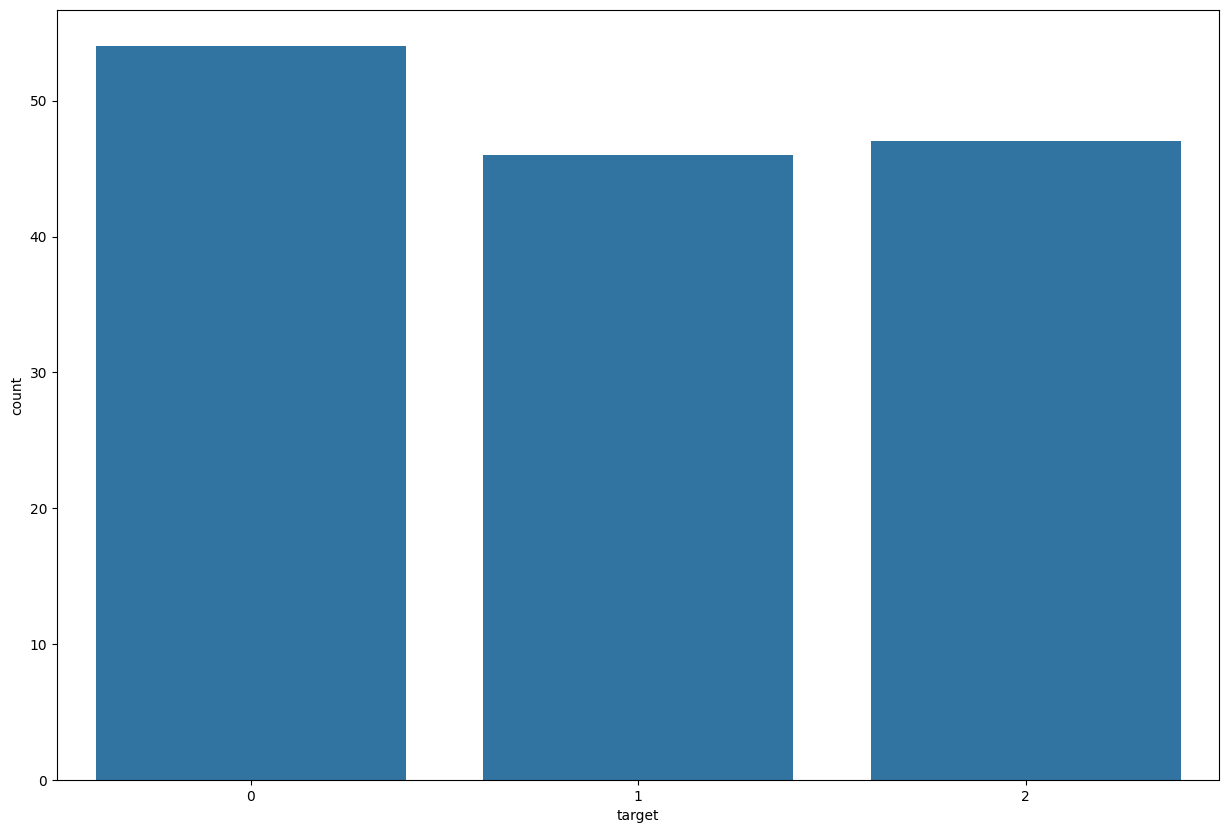

In [19]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='target')

<Axes: xlabel='target', ylabel='count'>

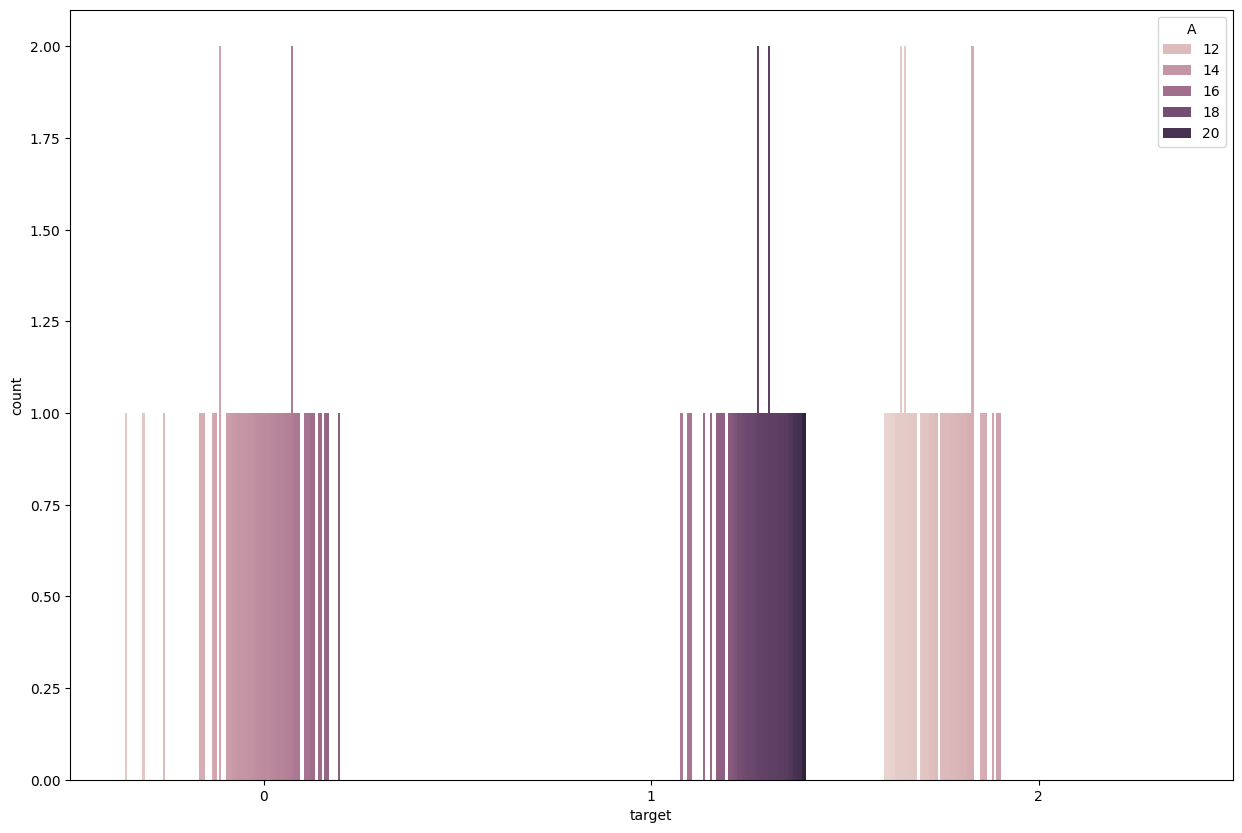

In [22]:
plt.figure(figsize=(15,10))
sns.countplot(data=train_data, x='target', hue='A')

In [25]:
# Separate features (X) and target (y) for the training data
X_train = train_data.drop('target', axis=1)
y_train = train_data['target']

# Import the DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=20)

# Fit the model to the training data
tree_clf.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [26]:
from sklearn import tree
text_representation = tree.export_text(tree_clf)
print(text_representation)

|--- feature_6 <= 5.62
|   |--- feature_0 <= 12.84
|   |   |--- feature_6 <= 4.72
|   |   |   |--- class: 0
|   |   |--- feature_6 >  4.72
|   |   |   |--- feature_0 <= 12.71
|   |   |   |   |--- feature_5 <= 1.54
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_5 >  1.54
|   |   |   |   |   |--- class: 2
|   |   |   |--- feature_0 >  12.71
|   |   |   |   |--- feature_4 <= 3.05
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_4 >  3.05
|   |   |   |   |   |--- class: 2
|   |--- feature_0 >  12.84
|   |   |--- feature_5 <= 5.27
|   |   |   |--- feature_4 <= 3.46
|   |   |   |   |--- class: 0
|   |   |   |--- feature_4 >  3.46
|   |   |   |   |--- feature_4 <= 3.47
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_4 >  3.47
|   |   |   |   |   |--- class: 0
|   |   |--- feature_5 >  5.27
|   |   |   |--- feature_0 <= 13.81
|   |   |   |   |--- class: 2
|   |   |   |--- feature_0 >  13.81
|   |   |   |   |--- class: 0
|--- feature_6 >  5.62
|   |-

In [27]:
from sklearn.metrics import accuracy_score

def accuracy(input_data,model,labels):
    """
    Take the input data, model and labels and return accuracy
    """
    preds = model.predict(input_data)
    acc = accuracy_score(labels,preds)
    return acc

In [28]:
from sklearn.metrics import confusion_matrix

def conf_matrix(input_data,model,labels):
    """
    Take the input data, model and labels and return confusion matrix
    """
    preds = model.predict(input_data)
    cm = confusion_matrix(labels,preds)

    return cm

In [29]:
from sklearn.metrics import classification_report

def class_report(input_data,model,labels):
    """
    Take the input data, model and labels and return confusion matrix
    """
    preds = model.predict(input_data)
    report = classification_report(labels,preds)
    report = print(report)

    return report


In [31]:
train_accuracy = accuracy(X_train, tree_clf, y_train)
print(f'Training Accuracy: {train_accuracy:.4f}')

Training Accuracy: 1.0000


In [33]:
train_conf_matrix = conf_matrix(X_train, tree_clf, y_train)
print('Confusion Matrix for Training Data:')
print(train_conf_matrix)

Confusion Matrix for Training Data:
[[54  0  0]
 [ 0 46  0]
 [ 0  0 47]]


In [34]:
class_report(X_train, tree_clf, y_train)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        46
           2       1.00      1.00      1.00        47

    accuracy                           1.00       147
   macro avg       1.00      1.00      1.00       147
weighted avg       1.00      1.00      1.00       147



In [35]:
tree_clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 20,
 'splitter': 'best'}

In [36]:

import warnings
warnings.filterwarnings('ignore')


In [38]:
from sklearn.model_selection import GridSearchCV

params_grid = {
               'max_leaf_nodes': list(range(2, 10)), # max_leaf_nodes must be > 1 or None
               'min_samples_split': list(range(2, 5)), # min_samples_split must be > 1 for integers
               'min_samples_leaf': list(range(1, 5)), # min_samples_leaf must be > 0 for integers
               'max_depth': list(range(1, 6)), # max_depth must be > 0 or None
               'max_features': list(range(1, 6)) # max_features must be > 0 or None
              }

#refit is true by default. The best estimator is trained on the whole dataset

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'), params_grid, verbose=1, cv=3, refit=True)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 2400 candidates, totalling 7200 fits


GridSearchCV(cv=3,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5],
                         'max_features': [1, 2, 3, 4, 5],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4]},
             verbose=1)

In [39]:
grid_search.best_params_

{'max_depth': 5,
 'max_features': 5,
 'max_leaf_nodes': 6,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [40]:
grid_search.best_estimator_

DecisionTreeClassifier(class_weight='balanced', max_depth=5, max_features=5,
                       max_leaf_nodes=6, random_state=42)

In [41]:
tree_best = grid_search.best_estimator_


In [42]:
seed_data.columns

Index(['A', 'P', 'C', 'LK', 'WK', 'A_Coef', 'LKG', 'target'], dtype='object')

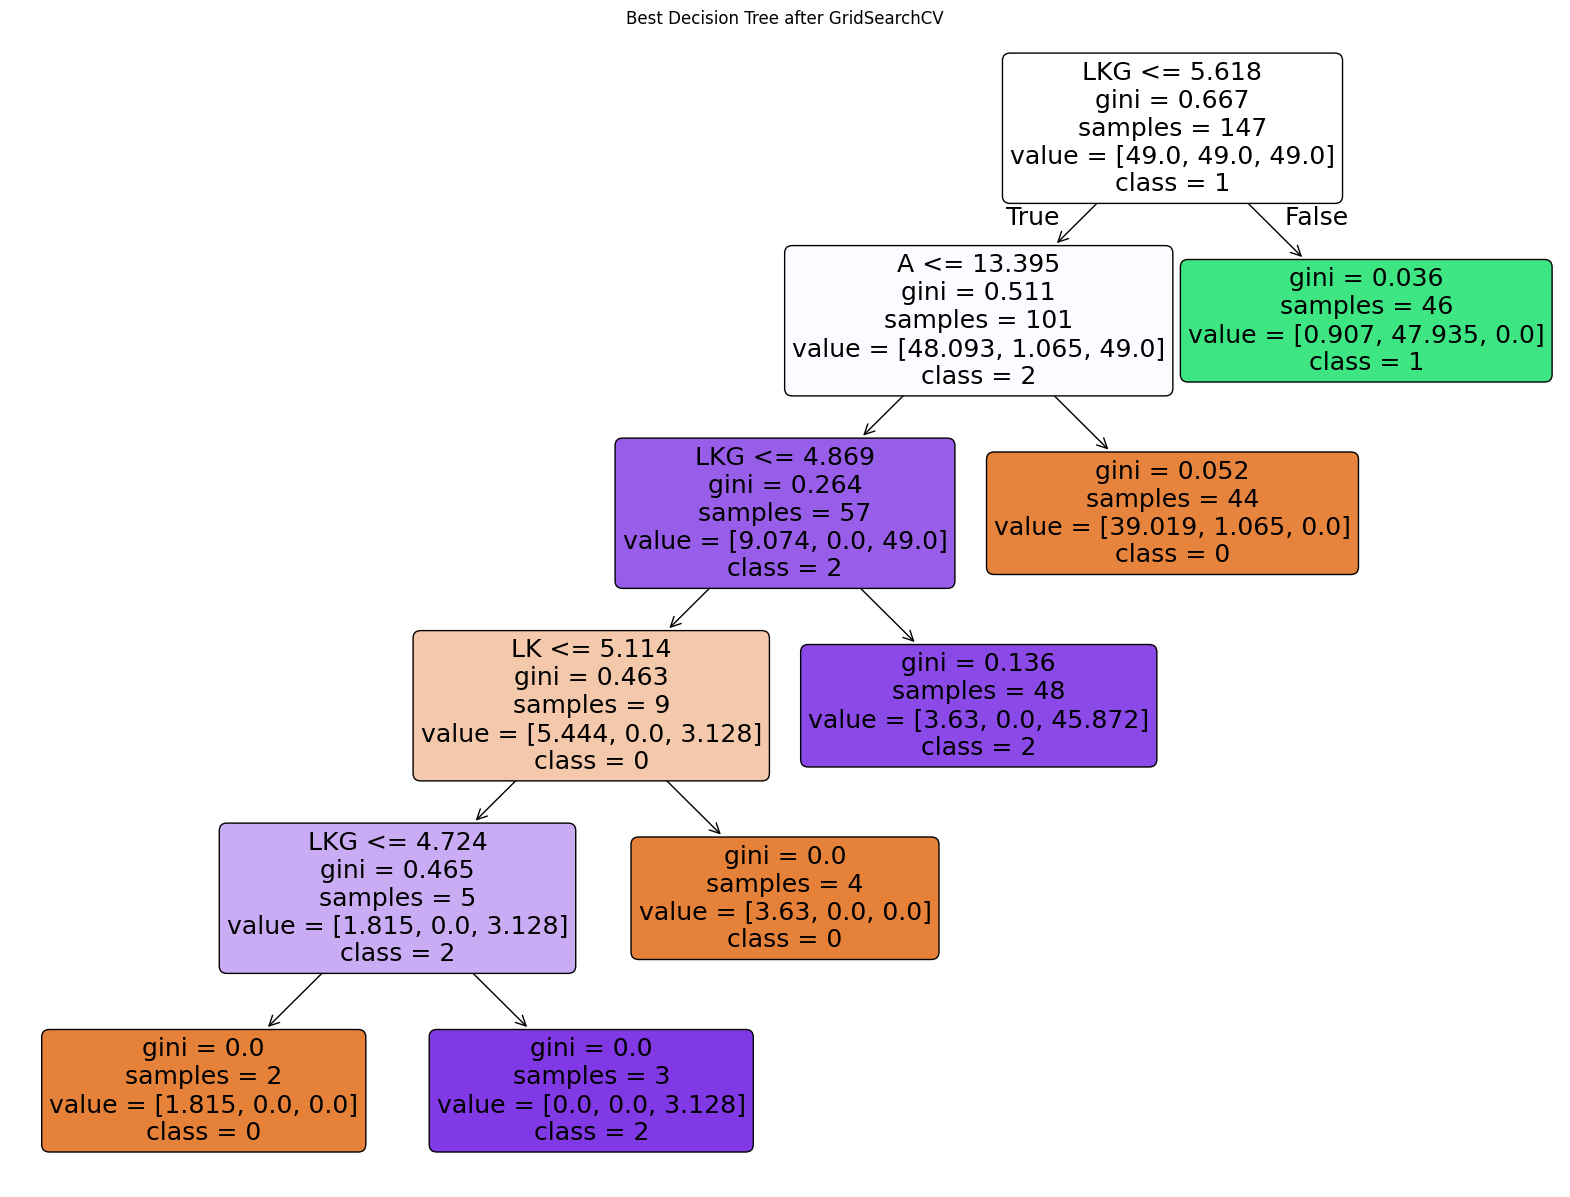

In [43]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
plot_tree(tree_best, feature_names=X_train.columns, class_names=[str(i) for i in sorted(y_train.unique())], filled=True, rounded=True)
plt.title('Best Decision Tree after GridSearchCV')
plt.show()

In [44]:
train_accuracy_best_model = accuracy(X_train, tree_best, y_train)
print(f'Training Accuracy with Best Model: {train_accuracy_best_model:.4f}')

Training Accuracy with Best Model: 0.9592


In [45]:
conf_matrix(X_train, tree_best, y_train)

array([[49,  1,  4],
       [ 1, 45,  0],
       [ 0,  0, 47]])

In [46]:
class_report(X_train, tree_best, y_train)

              precision    recall  f1-score   support

           0       0.98      0.91      0.94        54
           1       0.98      0.98      0.98        46
           2       0.92      1.00      0.96        47

    accuracy                           0.96       147
   macro avg       0.96      0.96      0.96       147
weighted avg       0.96      0.96      0.96       147



In [48]:
seed_test = test_data.drop('target', axis=1)
seed_test_labels = test_data['target']

In [49]:
test_accuracy_best_model = accuracy(seed_test, tree_best, seed_test_labels)
print(f'Test Accuracy with Best Model: {test_accuracy_best_model:.4f}')

Test Accuracy with Best Model: 0.9524


In [50]:
test_conf_matrix = conf_matrix(seed_test, tree_best, seed_test_labels)
print('Confusion Matrix for Test Data:')
print(test_conf_matrix)

Confusion Matrix for Test Data:
[[15  0  1]
 [ 2 22  0]
 [ 0  0 23]]


In [51]:
print('Classification Report for Test Data:')
class_report(seed_test, tree_best, seed_test_labels)

Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        16
           1       1.00      0.92      0.96        24
           2       0.96      1.00      0.98        23

    accuracy                           0.95        63
   macro avg       0.95      0.95      0.95        63
weighted avg       0.95      0.95      0.95        63

